In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tkinter as tk
from tkinter import filedialog
import mne, yaml

from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from scipy.signal import butter, sosfilt
from sklearn.linear_model import LogisticRegression

mne.set_log_level('WARNING')


def flatten_csp(X_csp, n_bands, n_comp):
    """Band-major flatten [n_win, n_bands, n_comp] → [n_win, n_bands*n_comp].
    Order: [band0_comp0..band0_compN | band1_comp0..band1_compN | ...]
    Matches Fbcsp.cpp column-major serialisation and flatten_csp() in training."""
    n_win = X_csp.shape[0]
    out = np.zeros((n_win, n_bands * n_comp))
    for b in range(n_bands):
        out[:, b * n_comp : (b + 1) * n_comp] = X_csp[:, b, :]
    return out


def get_fisher_score(X, y, classes):
    """Per-feature Fisher ratio: |µ1 - µ2|² / (σ1² + σ2²)."""
    mu1, mu2 = np.mean(X[y == classes[0]], 0), np.mean(X[y == classes[1]], 0)
    s1,  s2  = np.std( X[y == classes[0]], 0), np.std( X[y == classes[1]], 0)
    return np.abs(mu1 - mu2)**2 / (s1**2 + s2**2 + 1e-10)


In [2]:
root = tk.Tk()
root.withdraw() 

current_dir = os.getcwd()
current_dir = os.path.dirname(current_dir)
current_dir = os.path.dirname(current_dir)
current_dir = os.path.dirname(current_dir)

filenames = filedialog.askopenfilenames(
    title="Seleziona i file GDF", 
    filetypes=[("GDF Files", "*.gdf")],
    initialdir=current_dir
)

if not filenames:
    print("Nessun file selezionato!")
else:
    print(f"Selezionati {len(filenames)} file:")
    for f in filenames:
        print(f" - {f}")

    paradigm = os.path.splitext(os.path.basename(filenames[0]))[0].split('.')[-1]
    subject = os.path.splitext(os.path.basename(filenames[0]))[0].split('.')[0]
    
    # Determina le classi in base al nome del file
    if 'cvsa' in paradigm.lower():
        paradigm_to_save = 'cvsa'
        classes = ['730', '731']
    elif 'mi' in paradigm.lower():
        classes = ['769', '770']
        paradigm_to_save = 'mi'
    else:
        classes = ['771', '773']
        
    print(f"Paradigma: {paradigm}")
    print(f"Soggetto: {subject}")
    print(f"Classi: {classes}")

Selezionati 2 file:
 - /home/paolo/bci_vr_ws/recordings/c7/20260428/calibration/gdf/c7.20260428.123549.calibration.mi_lhrh.gdf
 - /home/paolo/bci_vr_ws/recordings/c7/20260428/calibration/gdf/c7.20260428.123954.calibration.mi_lhrh.gdf
Paradigma: mi_lhrh
Soggetto: c7
Classi: ['769', '770']


In [3]:
# ============================================================
# Preprocessing and epoching parameters
# ============================================================
# Sample rate of the recording (Hz)
FREQ        = 500

# Online pipeline parameters (must match the ROS launch file):
#   - The ring buffer in processing_bci is WINDOW_SIZE samples long (1 s at 500 Hz).
#   - A new chunk arrives every CHUNK_SIZE samples (= FREQ / framerate, framerate = 20 Hz online).
#   - Each new chunk produces one new FBCSP feature vector, i.e. one new online "window".
# Therefore consecutive online windows differ by exactly CHUNK_SIZE samples, and 20 consecutive
# windows are needed to fully refresh the ring buffer with new data after event 781.
CHUNK_SIZE   = 25            # online chunk size (samples) → also used as offline sliding-window step
WINDOW_SIZE  = FREQ * 1      # 1-second window (= ring-buffer length)
WINDOW_SHIFT = CHUNK_SIZE    # offline window shift: same as online so the training distribution
                             # matches the online inference distribution sample-for-sample.

# Frequency bands used for FBCSP (must match the ROS launch arg `filters_band`)
if 'mi' in paradigm.lower():
    BANDS = [[8,12], [12,16], [16,20], [20,26]]
else:
    BANDS = [[8,12], [10, 14], [12,16]]
BANDS_STR = [f"{b[0]}-{b[1]}Hz" for b in BANDS]

# Number of EEG channels in the recording (LiveAmp 32-ch)
N_CHANNELS = 32

# CSP components per band (top 4 + bottom 4 per band by default)
N_CSP_COMPONENTS = 4

# Channels excluded from CAR (frontal channels heavily contaminated by EOG)
EXCLUDE_CHANNELS = ['Fp1', 'Fp2']

# CVSA-specific: covert attention is reliable only at the start of each trial. Limit each CF
# segment to the first CVSA_INFLUENCE seconds to avoid training on data where the user has
# likely drifted. Set to None to use the full segment.
CVSA_INFLUENCE = 2.5 # must match the CVSA active window in the online Bayesian fusion (currently 2.5s from CF onset)

# ------------------------------------------------------------
# TRIM_START_S — offline / online alignment of the first window
# ------------------------------------------------------------
# Online behaviour after event 781 (CF onset at sample T):
#   - At T              ring buffer = [T-500, T]   → 500 cue, 0 CF
#   - At T + CHUNK_SIZE ring buffer = [T-475, T+25]→ 475 cue + 25 CF  ← 1st online window after CF
#   - At T + 2*CHUNK    ring buffer = [T-450, T+50]→ 450 cue + 50 CF
#   - ...
#   - At T + WINDOW_SIZE ring buffer = [T, T+500] → 0 cue + 500 CF    ← 1st 100%-CF window
#
# DEFAULT: -(WINDOW_SIZE - CHUNK_SIZE) / FREQ = -0.95 s  → first training window starts at
#   onset - 475, contains 475 pre-CF + 25 CF samples → EXACTLY the first window the online
#   classifier sees after event 781. This way the training distribution matches the inference
#   distribution from the very first online prediction.
#
# Other useful values:
#   TRIM_START_S =  0.0  → first window is 100% CF (skips all transient online windows)
#   TRIM_START_S =  0.5  → extra warmup, even more conservative
#   TRIM_START_S = -1.0  → first window is 100% cue (do NOT use; here only for reference)
TRIM_START_S = -(WINDOW_SIZE - CHUNK_SIZE) / FREQ   # = -0.95 s by default

# Per-paradigm channel subset used to compute CSP (loaded by Fbcsp.cpp at runtime).
if 'mi' in paradigm.lower():
    SELECTED_CHANNELS = ['FC5', 'FC1', 'C3', 'CP5', 'CP1', 'CP6', 'CP2', 'Cz', 'C4', 'FC6', 'FC2']
elif 'cvsa' in paradigm.lower():
    SELECTED_CHANNELS = ['P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'Oz', 'O2']


In [4]:
# ============================================================
# Load GDF files, apply CAR (matches ROS), and extract sliding-window epochs.
# ============================================================
# Pipeline per recording:
#   1. Read GDF with MNE, keep only the first N_CHANNELS EEG channels.
#   2. Apply Common Average Reference (CAR), excluding EXCLUDE_CHANNELS — identical
#      to what rosneuro_filters_car does online.
#   3. Apply per-band causal Butterworth filter (LP → HP, order 4) — identical to
#      Fbcsp.cpp (filters_low_[i] applied before filters_high_[i]).
#   4. Slide a 1-second window over each Continuous-Feedback segment (between
#      event 781 and event 33549) with step = CHUNK_SIZE (= online behavior).
# ============================================================
raw_list = []
for f in filenames:
    with mne.utils.use_log_level('ERROR'):
        raw = mne.io.read_raw_gdf(f, preload=True)
        raw = raw.pick(list(range(N_CHANNELS)))

        # CAR computed over channels NOT listed in EXCLUDE_CHANNELS.
        # This matches the online behavior of rosneuro_filters_car, which uses the
        # EOG_ch_names entry of car.yaml to decide which channels to exclude.
        data = raw.get_data()
        excl_idx = [raw.ch_names.index(ch) for ch in EXCLUDE_CHANNELS if ch in raw.ch_names]
        include_mask = np.ones(N_CHANNELS, dtype=bool)
        include_mask[excl_idx] = False
        common_avg = data[include_mask, :].mean(axis=0)
        data -= common_avg[np.newaxis, :]
        raw._data = data

    raw_list.append(raw)

# Channel indices used by CSP — names are resolved against the first recording's labels.
SELECTED_INDEX_CH = [raw.ch_names.index(ch) for ch in SELECTED_CHANNELS if ch in raw.ch_names]

# Storage for the sliding-window epochs.
X_epochs  = []   # (n_epochs, n_bands, n_channels, WINDOW_SIZE)
y_epochs  = []   # class label per epoch
trials    = []   # trial index per epoch — used as groups= in StratifiedGroupKFold (no same-trial leakage)
t_centers = []   # center time of each window relative to CF onset (seconds); negative = pre-CF (cue) period
trial_idx = 0

# Convert TRIM_START_S to samples once. The loop below starts each trial's epochs at
#   s_first = onset + trim_start_samples
# i.e. the first window covers [s_first, s_first + WINDOW_SIZE]. With TRIM_START_S = 0 this
# is exactly the first 100%-CF window in online terms (online emits it at processing time
# onset + WINDOW_SIZE because the ring buffer takes WINDOW_SIZE samples to refresh).
trim_start_samples = int(TRIM_START_S * FREQ)

for raw in raw_list:
    # -------- Detect Continuous-Feedback segments via GDF annotations --------
    # A trial is delimited by three events:
    #   1. class code in `classes` (e.g. 730/731 for CVSA, 769/770 for MI) → trial class
    #   2. 781   → start of Continuous Feedback (CF) within the trial
    #   3. 33549 → end of trial (CF stops here)
    # Only the [781, 33549] sub-segment is used for training.
    cf_segments  = []
    current_class = None
    onset_sample  = None

    for annot in raw.annotations:
        desc = annot['description']

        if desc in classes:
            current_class = desc

        elif desc == '781':
            onset_sample = int(annot['onset'] * FREQ)

        elif desc == '33549':
            if current_class is not None and onset_sample is not None:
                end_sample       = int(annot['onset'] * FREQ)
                duration_samples = end_sample - onset_sample
                cf_segments.append((onset_sample, duration_samples, current_class))
                current_class = None
                onset_sample  = None

    # -------- Per-band causal Butterworth filtering (LP → HP, matches Fbcsp.cpp) --------
    # Filter initial conditions are zero (np.zeros), NOT sosfilt_zi steady-state — this
    # matches both the ROS implementation and the MATLAB reference filter ICs.
    raw_bands = []
    data_car  = raw.get_data()   # CAR-filtered data (n_channels, n_samples)
    for l_freq, h_freq in BANDS:
        sos_lp = butter(4, h_freq, btype='lowpass',  fs=FREQ, output='sos')
        sos_hp = butter(4, l_freq, btype='highpass', fs=FREQ, output='sos')

        # zero initial conditions, shape (n_sections, n_channels, 2)
        zi_lp = np.zeros((sos_lp.shape[0], data_car.shape[0], 2))
        data_lp, _ = sosfilt(sos_lp, data_car, zi=zi_lp)

        zi_hp = np.zeros((sos_hp.shape[0], data_lp.shape[0], 2))
        filtered, _ = sosfilt(sos_hp, data_lp, zi=zi_hp)

        raw_bands.append(filtered)

    # -------- Sliding-window epoching, simulating the online ring buffer --------
    # The window step (WINDOW_SHIFT = CHUNK_SIZE = 25 samples) matches the online pipeline:
    # each new online chunk shifts the ring-buffer view by exactly CHUNK_SIZE samples,
    # so consecutive training epochs differ by the same amount as consecutive online windows.
    for onset, duration, cls in cf_segments:
        end = onset + duration

        # CVSA only: restrict each CF segment to its first CVSA_INFLUENCE seconds, because
        # covert attention is reliable only at trial onset (the user drifts afterwards).
        if paradigm_to_save == 'cvsa' and CVSA_INFLUENCE is not None:
            end = min(end, onset + int(CVSA_INFLUENCE * FREQ))

        # First window starts `trim_start_samples` AFTER the CF onset. With TRIM_START_S = 0
        # the window is fully CF (cleanest case, matches first 100%-CF online window).
        s_first = onset + trim_start_samples
        s_last  = end - WINDOW_SIZE                 # inclusive; window must fit entirely in CF segment

        for s in range(s_first, s_last + 1, WINDOW_SHIFT):
            # Each epoch contains one WINDOW_SIZE slice per frequency band.
            window_bands = [raw_bands[b][:, s : s + WINDOW_SIZE] for b in range(len(BANDS))]
            X_epochs.append(np.array(window_bands))
            y_epochs.append(cls)
            trials.append(trial_idx)
            t_centers.append((s + WINDOW_SIZE / 2 - onset) / FREQ)
        trial_idx += 1

X_epochs  = np.array(X_epochs)   # shape: (n_epochs, n_bands, n_channels, n_samples)
y_epochs  = np.array(y_epochs)
trials    = np.array(trials)
t_centers = np.array(t_centers)

print(f"Extracted {len(X_epochs)} windows across {len(np.unique(trials))} trials.")
print(f"X_epoch shape: {X_epochs.shape} (n_epochs, n_bands, n_channels, n_samples)")
print(f"Window shift = {WINDOW_SHIFT} samples ({WINDOW_SHIFT / FREQ * 1000:.1f} ms) — matches online")
print(f"Trim start   = {trim_start_samples} samples ({TRIM_START_S:+.2f} s after CF onset)")




Extracted 3733 windows across 40 trials.
X_epoch shape: (3733, 4, 32, 500) (n_epochs, n_bands, n_channels, n_samples)
Window shift = 25 samples (50.0 ms) — matches online
Trim start   = -475 samples (-0.95 s after CF onset)


--- 4-fold StratifiedGroupKFold ---
  Fold 1: 30 train / 10 test trials | train 0.835  test 0.603  gap +0.232
  Fold 2: 30 train / 10 test trials | train 0.839  test 0.733  gap +0.106
  Fold 3: 30 train / 10 test trials | train 0.809  test 0.637  gap +0.172
  Fold 4: 30 train / 10 test trials | train 0.813  test 0.659  gap +0.154

────────────────────────────────────────────────────────
  CV  |  K=4  shrinkage='auto'  priors=[0.5, 0.5]
  Features : 16  (4 bands x 4 components)  |  ratio : 1.2x
────────────────────────────────────────────────────────
  Balanced accuracy   : 0.658 +/- 0.048  [MARGINAL]
  Fold variance sigma : 0.048  [stable]
  Train-test gap      : +0.166  [expected with small N — watch sigma, not gap]
────────────────────────────────────────────────────────
  ! ratio < 3 — high overfit risk: reduce bands or components
────────────────────────────────────────────────────────



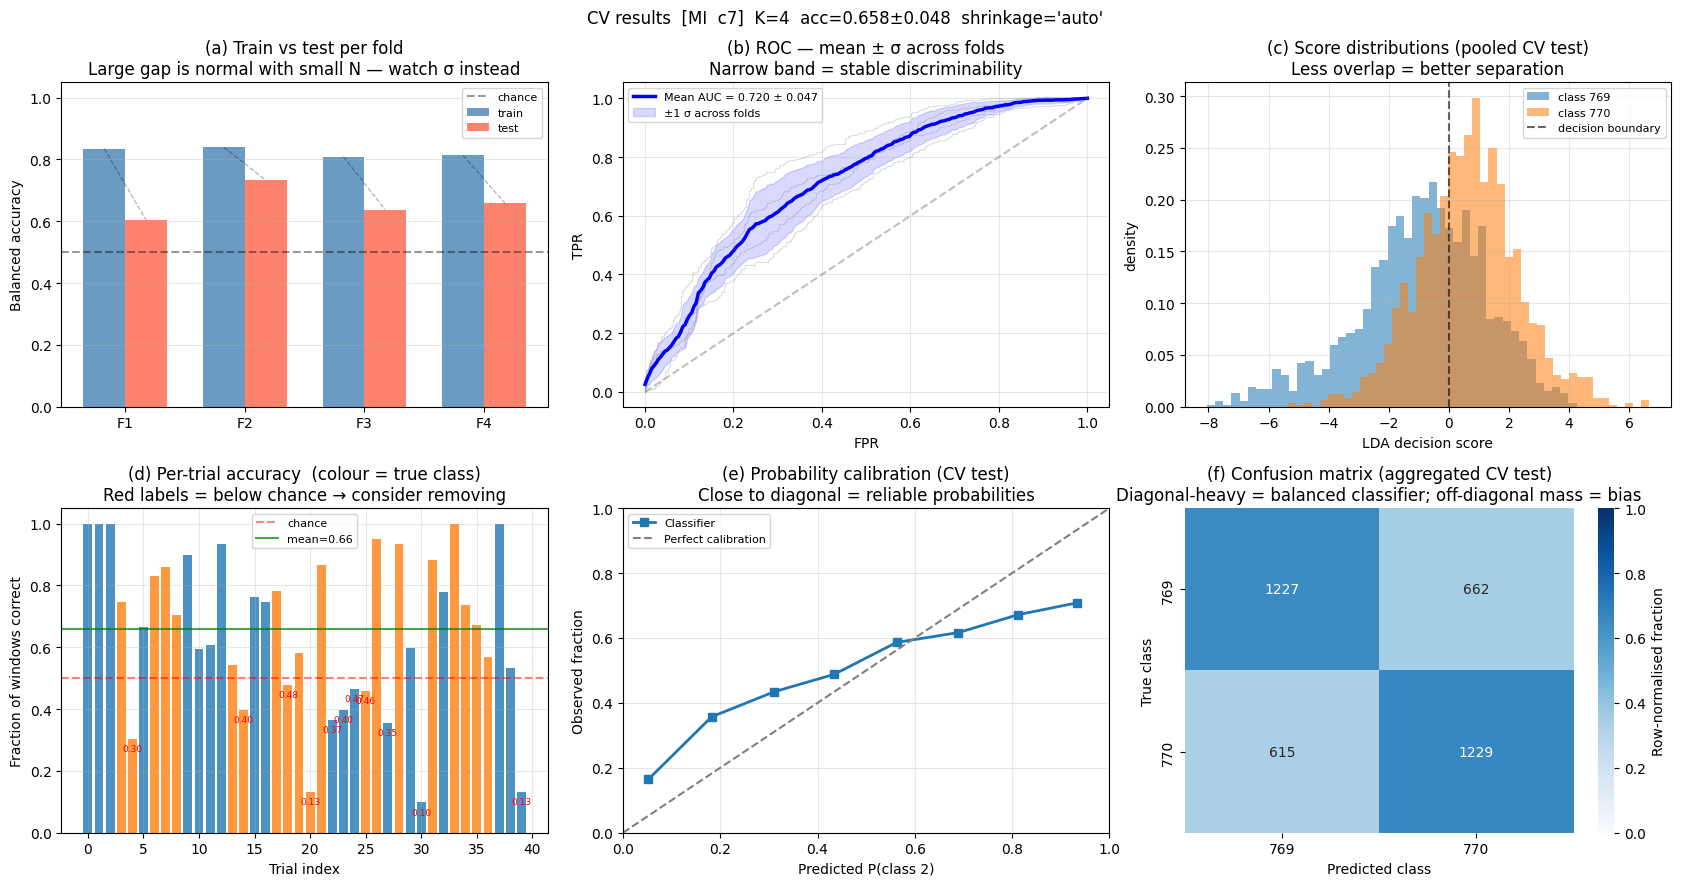

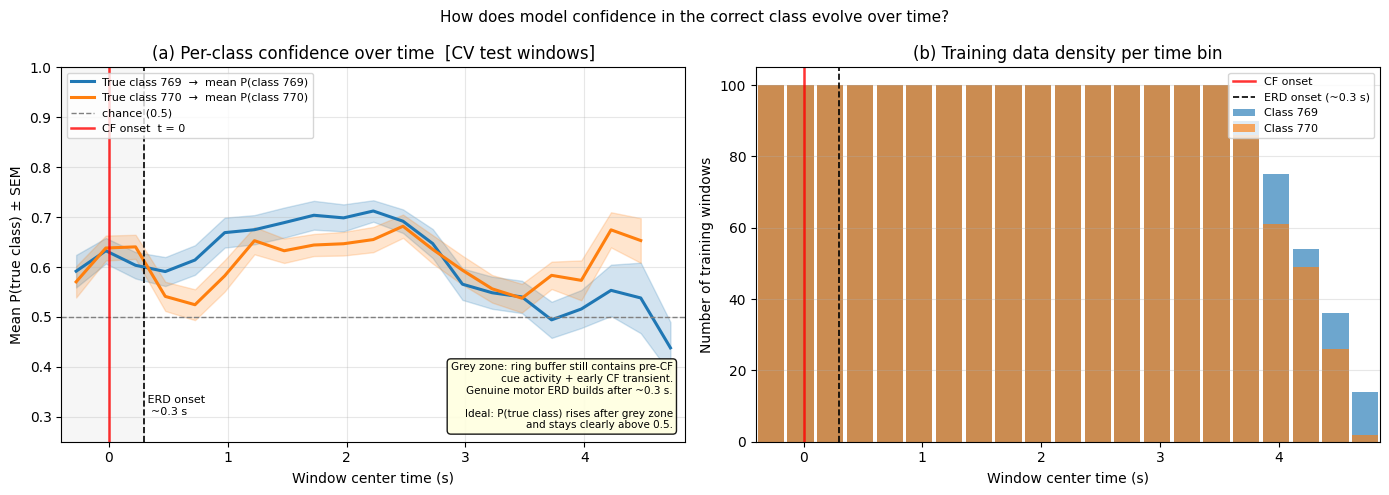

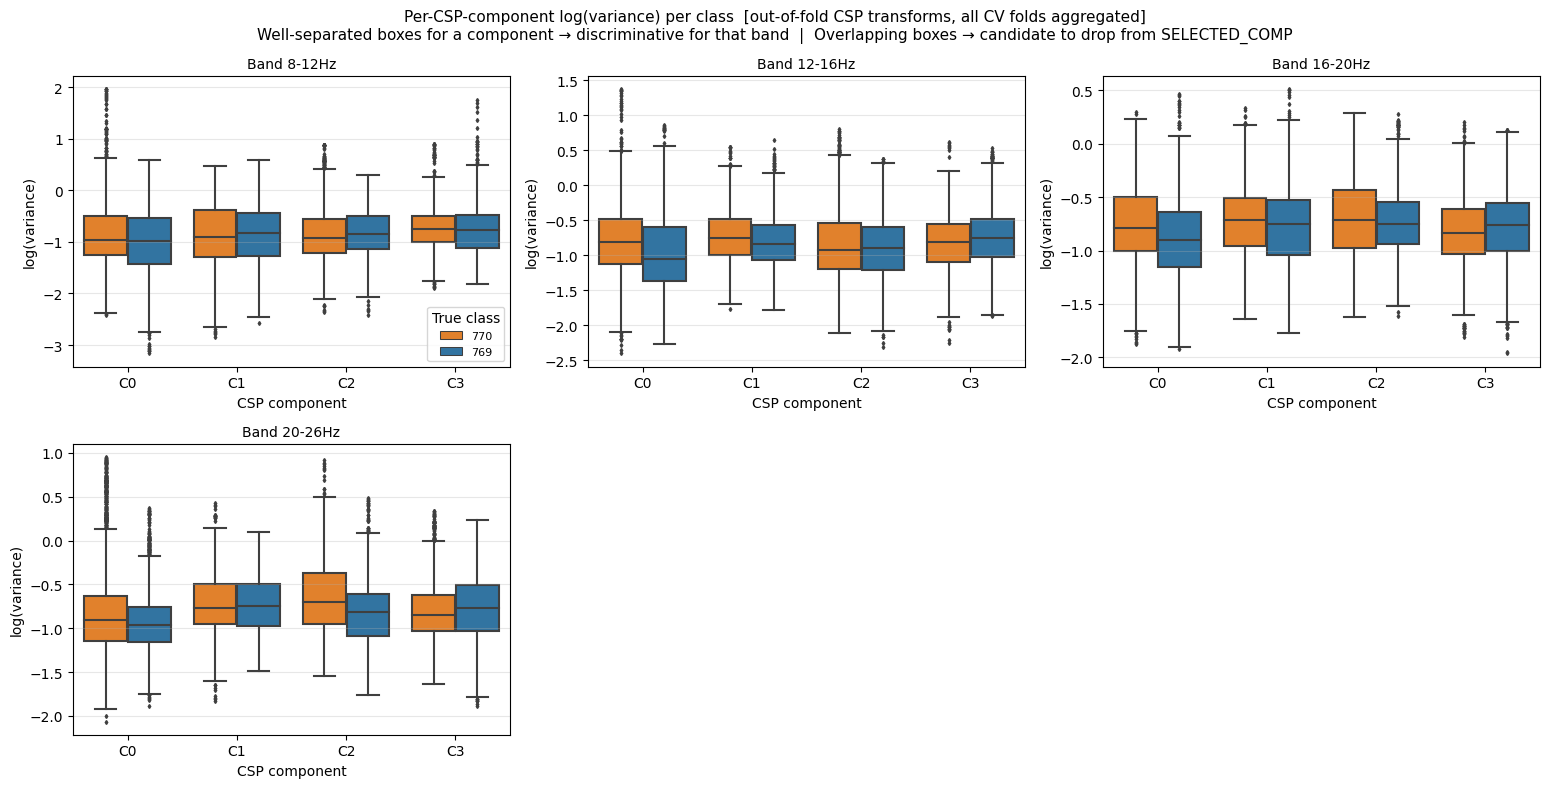

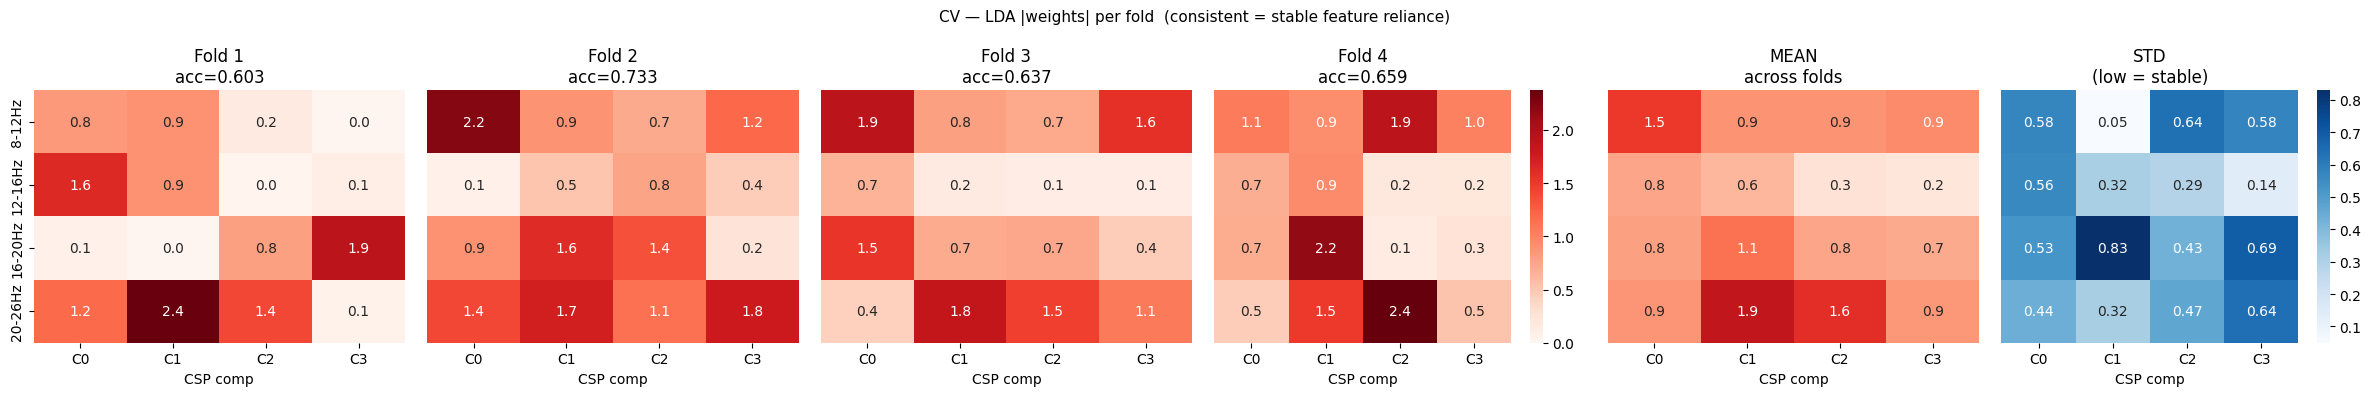

In [5]:
# ── Hyperparameters ───────────────────────────────────────────────────────
LDA_SHRINKAGE = 'auto'    # 'auto' = Ledoit-Wolf | None = MLE | float ∈ [0,1]
LDA_PRIORS    = [0.5, 0.5]
K_FOLDS       = 4         # 5 → ~80/20 | 4 → 75/25 | 3 → 66/33
SELECTED_COMP = list(range(N_CSP_COMPONENTS))   # drop components if Figs 3-4 show none-zero weights
selected_indices = SELECTED_COMP                 # alias for save + topoplot cells
n_sel = len(SELECTED_COMP)

# ── CV loop (CSP + sLDA refit per fold, no same-trial leakage) ────────────
# all_X_csp_oof[i] = CSP transform of window i using the fold-CSP that did NOT see window i.
# This gives an unbiased view of what the deployed pipeline would compute for each window.
all_X_csp_oof = np.zeros((len(X_epochs), len(BANDS), N_CSP_COMPONENTS))

sgkf = StratifiedGroupKFold(n_splits=K_FOLDS)
fold_clfs, fold_train_accs, fold_test_accs = [], [], []
fold_cms, fold_fpr_list, fold_tpr_list = [], [], []
all_y_true, all_y_pred, all_scores, all_trials_cv, all_t_centers = [], [], [], [], []

print(f"--- {K_FOLDS}-fold StratifiedGroupKFold ---")
for fold_idx, (tr_idx, te_idx) in enumerate(
        sgkf.split(X_epochs, y_epochs, groups=trials), 1):

    X_tr_csp = np.zeros((len(tr_idx), len(BANDS), N_CSP_COMPONENTS))
    X_te_csp = np.zeros((len(te_idx), len(BANDS), N_CSP_COMPONENTS))
    for b in range(len(BANDS)):
        csp_f = CSP(n_components=N_CSP_COMPONENTS, reg='ledoit_wolf', log=True,
                    norm_trace=False, component_order='alternate')
        csp_f.fit(X_epochs[tr_idx][:, b, SELECTED_INDEX_CH, :], y_epochs[tr_idx])
        X_tr_csp[:, b, :] = csp_f.transform(X_epochs[tr_idx][:, b, SELECTED_INDEX_CH, :])
        X_te_csp[:, b, :] = csp_f.transform(X_epochs[te_idx][:, b, SELECTED_INDEX_CH, :])

    all_X_csp_oof[te_idx] = X_te_csp   # store out-of-fold transforms

    X_tr = flatten_csp(X_tr_csp[:, :, SELECTED_COMP], len(BANDS), n_sel)
    X_te = flatten_csp(X_te_csp[:, :, SELECTED_COMP], len(BANDS), n_sel)
    y_tr, y_te = y_epochs[tr_idx], y_epochs[te_idx]

    clf = LinearDiscriminantAnalysis(solver='lsqr', shrinkage=LDA_SHRINKAGE, priors=LDA_PRIORS)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    scores = clf.decision_function(X_te)

    acc_tr = balanced_accuracy_score(y_tr, clf.predict(X_tr))
    acc_te = balanced_accuracy_score(y_te, y_pred)
    fold_train_accs.append(acc_tr); fold_test_accs.append(acc_te)
    fold_cms.append(confusion_matrix(y_te, y_pred, labels=classes))
    fold_clfs.append(clf)

    fpr_f, tpr_f, _ = roc_curve((y_te == classes[1]).astype(int), scores)
    fold_fpr_list.append(fpr_f); fold_tpr_list.append(tpr_f)

    all_y_true.append(y_te);  all_y_pred.append(y_pred)
    all_scores.append(scores); all_trials_cv.append(trials[te_idx])
    all_t_centers.append(t_centers[te_idx])

    print(f"  Fold {fold_idx}: {len(np.unique(trials[tr_idx])):2d} train / "
          f"{len(np.unique(trials[te_idx])):2d} test trials | "
          f"train {acc_tr:.3f}  test {acc_te:.3f}  gap {acc_tr-acc_te:+.3f}")

all_y_true    = np.concatenate(all_y_true)
all_y_pred    = np.concatenate(all_y_pred)
all_scores    = np.concatenate(all_scores)
all_trials_cv = np.concatenate(all_trials_cv)
all_t_centers = np.concatenate(all_t_centers)
mean_acc = float(np.mean(fold_test_accs))
std_acc  = float(np.std(fold_test_accs))
mean_cm  = np.sum(fold_cms, axis=0)
mean_gap = float(np.mean(np.array(fold_train_accs) - np.array(fold_test_accs)))

# P(predicted = true class) per window — model confidence in the correct answer.
# More informative than 0/1 accuracy: shows HOW SURE the model is.
prob_class1 = 1 / (1 + np.exp(-all_scores))
prob_correct = np.where(all_y_true == classes[1], prob_class1, 1 - prob_class1)

# ── CV summary ────────────────────────────────────────────────────────────
n_features = len(BANDS) * n_sel
ratio      = (len(np.unique(trials)) // 2) / n_features

sep     = "─" * 56
quality = "GOOD" if mean_acc >= 0.75 else ("MARGINAL" if mean_acc >= 0.65 else "WEAK")
std_ok  = std_acc < 0.08
rat_ok  = ratio   >= 5

print(f"\n{sep}")
print(f"  CV  |  K={K_FOLDS}  shrinkage={LDA_SHRINKAGE!r}  priors={LDA_PRIORS}")
print(f"  Features : {n_features}  ({len(BANDS)} bands x {n_sel} components)  |  ratio : {ratio:.1f}x")
print(f"{sep}")
print(f"  Balanced accuracy   : {mean_acc:.3f} +/- {std_acc:.3f}  [{quality}]")
print(f"  Fold variance sigma : {std_acc:.3f}  [{'stable' if std_ok else 'UNSTABLE — reduce features'}]")
print(f"  Train-test gap      : {mean_gap:+.3f}  [expected with small N — watch sigma, not gap]")
print(f"{sep}")

# Warnings — printed only when actionable
if not rat_ok:
    thr = "< 3 — high overfit risk" if ratio < 3 else "< 5 — borderline, Ledoit-Wolf essential"
    print(f"  ! ratio {thr}: reduce bands or components")
if not std_ok:
    print("  ! High fold sigma (> 8%) — model may be struggling to generalize. Recommendation: reduce N_CSP_COMPONENTS to 2 to halve feature size and check per-trial panel for outliers.")
if mean_acc < 0.65:
    print("  ! Weak signal — verify SELECTED_CHANNELS and BANDS for this paradigm")

print(f"{sep}\n")

auc_scores = [auc(f, t) for f, t in zip(fold_fpr_list, fold_tpr_list)]


# ── Fig 1: aggregate CV analyses ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle(
    f"CV results  [{paradigm_to_save.upper()}  {subject}]  "
    f"K={K_FOLDS}  acc={mean_acc:.3f}±{std_acc:.3f}  shrinkage={LDA_SHRINKAGE!r}",
    fontsize=12)

# (a) Train vs test balanced accuracy per fold
ax = axes[0, 0]
x = np.arange(K_FOLDS); w = 0.35
ax.bar(x - w/2, fold_train_accs, w, label='train', color='steelblue', alpha=0.8)
ax.bar(x + w/2, fold_test_accs,  w, label='test',  color='tomato',    alpha=0.8)
ax.axhline(0.5, color='k', linestyle='--', alpha=0.4, label='chance')
for xi, (tr, te) in enumerate(zip(fold_train_accs, fold_test_accs)):
    ax.plot([xi - w/2, xi + w/2], [tr, te], 'k--', alpha=0.3, lw=0.9)
ax.set_xticks(x); ax.set_xticklabels([f'F{i+1}' for i in x])
ax.set(ylabel='Balanced accuracy', ylim=[0, 1.05],
       title='(a) Train vs test per fold\nLarge gap is normal with small N — watch σ instead')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

# (b) ROC — mean ± std across folds
ax = axes[0, 1]
mean_fpr    = np.linspace(0, 1, 200)
tprs_interp = [np.interp(mean_fpr, f, t) for f, t in zip(fold_fpr_list, fold_tpr_list)]
mean_tpr    = np.mean(tprs_interp, axis=0)
std_tpr     = np.std(tprs_interp, axis=0)
for fpr_f, tpr_f in zip(fold_fpr_list, fold_tpr_list):
    ax.plot(fpr_f, tpr_f, color='gray', alpha=0.25, lw=0.8)
ax.plot(mean_fpr, mean_tpr, 'b', lw=2.5,
        label=f'Mean AUC = {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}')
ax.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                alpha=0.15, color='b', label='±1 σ across folds')
ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
ax.set(xlabel='FPR', ylabel='TPR',
       title='(b) ROC — mean ± σ across folds\nNarrow band = stable discriminability')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (c) LDA score distributions pooled from all CV test folds
ax = axes[0, 2]
for i, cls in enumerate(classes):
    ax.hist(all_scores[all_y_true == cls], bins=45, alpha=0.55,
            density=True, label=f'class {cls}', color=f'C{i}')
ax.axvline(0, color='k', linestyle='--', alpha=0.6, label='decision boundary')
ax.set(xlabel='LDA decision score', ylabel='density',
       title='(c) Score distributions (pooled CV test)\nLess overlap = better separation')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (d) Per-trial window accuracy — reveals which trials are hard
ax = axes[1, 0]
unique_t = np.unique(all_trials_cv)
t_accs, t_cls = [], []
for t in unique_t:
    m = all_trials_cv == t
    t_accs.append(np.mean(all_y_true[m] == all_y_pred[m]))
    t_cls.append(all_y_true[m][0])
ax.bar(unique_t, t_accs, color=['C0' if c == classes[0] else 'C1' for c in t_cls], alpha=0.8)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='chance')
ax.axhline(np.mean(t_accs), color='green', alpha=0.7, label=f'mean={np.mean(t_accs):.2f}')
for t, acc in zip(unique_t, t_accs):
    if acc < 0.5:
        ax.text(t, acc - 0.04, f'{acc:.2f}', ha='center', fontsize=6.5, color='red')
ax.set(xlabel='Trial index', ylabel='Fraction of windows correct',
       title='(d) Per-trial accuracy  (colour = true class)\nRed labels = below chance → consider removing')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (e) Probability calibration: predicted P vs observed frequency
ax = axes[1, 1]
frac_pos, mean_pred = calibration_curve(
    (all_y_true == classes[1]).astype(int), prob_class1, n_bins=8, strategy='uniform')
ax.plot(mean_pred, frac_pos, 's-', lw=2, label='Classifier')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
ax.set(xlabel='Predicted P(class 2)', ylabel='Observed fraction',
       title='(e) Probability calibration (CV test)\nClose to diagonal = reliable probabilities',
       xlim=[0, 1], ylim=[0, 1])
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (f) Confusion matrix — row-normalized; shows misclassification asymmetries
ax = axes[1, 2]
cm_norm = mean_cm / mean_cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=mean_cm.astype(int), fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax, vmin=0, vmax=1,
            cbar_kws={'label': 'Row-normalised fraction'})
ax.set(xlabel='Predicted class', ylabel='True class',
       title='(f) Confusion matrix (aggregated CV test)\n'
             'Diagonal-heavy = balanced classifier; off-diagonal mass = bias')

plt.tight_layout(); plt.show()


# ── Fig 2: P(predicted = true class) vs time — model confidence per class ─
#
# For each window the model emits P(predicted=true class).
# Plotted as mean ± SEM, separately for windows whose TRUE label is class 0 vs class 1.
# Reads as: "given a class-X trial, how confident is the model that it's class X over time?"
#
# Interpretation cutoffs (paradigm-specific):
#   MI:   genuine motor ERD builds ~0.3 s after CF onset → grey zone before 0.3 s
#         is a mix of cue and early CF, model confidence there is suspect.
#   CVSA: a VEP from the grating peaks at 0.1–0.2 s and decays by ~0.7 s →
#         confidence in the orange zone may exploit the VEP, not covert attention.

BINS_S = np.arange(round(all_t_centers.min(), 1),
                   round(all_t_centers.max(), 1) + 0.25, 0.25)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "How does model confidence in the correct class evolve over time?",
    fontsize=11)

# Panel A: per-class P(true class) ± SEM over time
ax = axes[0]
for c_i, cls in enumerate(classes):
    mask = all_y_true == cls
    df_c = pd.DataFrame({'t': all_t_centers[mask], 'p': prob_correct[mask]})
    df_c['bin'] = pd.cut(df_c['t'], bins=BINS_S)
    grp    = df_c.groupby('bin', observed=True)['p']
    b_mean = grp.mean()
    b_sem  = grp.std() / np.sqrt(grp.count())
    t_mid  = np.array([b.mid for b in b_mean.index])
    ax.plot(t_mid, b_mean.values, color=f'C{c_i}', lw=2.2,
            label=f'True class {cls}  →  mean P(class {cls})')
    ax.fill_between(t_mid,
                    b_mean.values - b_sem.values,
                    b_mean.values + b_sem.values,
                    alpha=0.2, color=f'C{c_i}')

ax.axhline(0.5, color='gray', linestyle='--', lw=1, label='chance (0.5)')
ax.axvline(0.0, color='red',  lw=1.8, alpha=0.8, label='CF onset  t = 0')

if paradigm_to_save == 'mi':
    ax.axvspan(all_t_centers.min(), 0.3, alpha=0.07, color='gray')
    ax.axvline(0.3, color='k', lw=1.2, linestyle='--')
    ax.text(0.30, 0.30, ' ERD onset\n  ~0.3 s', fontsize=8, color='k', va='bottom')
    note = ("Grey zone: ring buffer still contains pre-CF\n"
            "cue activity + early CF transient.\n"
            "Genuine motor ERD builds after ~0.3 s.\n\n"
            "Ideal: P(true class) rises after grey zone\n"
            "and stays clearly above 0.5.")
elif paradigm_to_save == 'cvsa':
    ax.axvspan(0, 0.7, alpha=0.08, color='orange')
    ax.axvline(0.7, color='darkorange', lw=1.2, linestyle='--')
    ax.text(0.72, 0.30, 'VEP decay\n~0.7 s', fontsize=8, color='darkorange', va='bottom')
    note = ("Orange zone: VEP from grating onset.\n"
            "Peaks 0.1–0.2 s, decays by ~0.7 s.\n\n"
            "High confidence here may reflect the\n"
            "stimulus-locked VEP, not covert attention.\n"
            "Consider raising TRIM_START_S to ~0.7 s.")
else:
    note = ""

if note:
    ax.text(0.98, 0.03, note, transform=ax.transAxes,
            fontsize=7.5, va='bottom', ha='right',
            bbox=dict(boxstyle='round,pad=0.35', fc='lightyellow', alpha=0.9))

ax.set(xlabel='Window center time (s)',
       ylabel='Mean P(true class) ± SEM',
       xlim=[BINS_S[0], BINS_S[-1]], ylim=[0.25, 1.0],
       title='(a) Per-class confidence over time  [CV test windows]')
ax.legend(fontsize=8, loc='upper left'); ax.grid(alpha=0.3)

# Panel B: data density per time bin
ax = axes[1]
for c_i, cls in enumerate(classes):
    mask = all_y_true == cls
    counts, edges = np.histogram(all_t_centers[mask], bins=BINS_S)
    mid = (edges[:-1] + edges[1:]) / 2
    ax.bar(mid, counts, width=0.22, alpha=0.65, color=f'C{c_i}',
           label=f'Class {cls}', align='center')

ax.axvline(0.0, color='red', lw=1.8, alpha=0.8, label='CF onset')
if paradigm_to_save == 'mi':
    ax.axvline(0.3, color='k', lw=1.2, linestyle='--', label='ERD onset (~0.3 s)')
elif paradigm_to_save == 'cvsa':
    ax.axvline(0.7, color='darkorange', lw=1.2, linestyle='--', label='VEP decay (~0.7 s)')
    if CVSA_INFLUENCE is not None:
        ax.axvline(CVSA_INFLUENCE, color='purple', lw=1.2, linestyle='-.',
                   label=f'CVSA_INFLUENCE = {CVSA_INFLUENCE} s')

ax.set(xlabel='Window center time (s)',
       ylabel='Number of training windows',
       xlim=[BINS_S[0], BINS_S[-1]],
       title='(b) Training data density per time bin')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()


# ── Fig 3: per-CSP-component log(variance) per class (out-of-fold) ────────
# CSP with log=True returns log(variance). For each component (C0..CN-1) in each band,
# the boxplots show how class 0 vs class 1 windows distribute on that single feature.
# Two well-separated boxes per component → that component IS discriminative.
# Two overlapping boxes → that component carries little class information.
# Use this to decide which SELECTED_COMP to keep / drop in the hyperparameter cell.
# Transforms used here are out-of-fold (each window passes through a CSP that didn't see it).

n_bands_plot = len(BANDS)
nrows = int(np.ceil(n_bands_plot / 3))
ncols = min(3, n_bands_plot)
fig, axes_grid = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4 * nrows), squeeze=False)
axes_flat = axes_grid.flatten()
palette = {classes[0]: 'C0', classes[1]: 'C1'}

for b in range(n_bands_plot):
    ax = axes_flat[b]
    data_b = all_X_csp_oof[:, b, :]
    df_b = pd.DataFrame(data_b, columns=[f'C{c}' for c in range(N_CSP_COMPONENTS)])
    df_b['class'] = all_y_true
    df_long = df_b.melt(id_vars='class', var_name='Component', value_name='log(variance)')
    sns.boxplot(data=df_long, x='Component', y='log(variance)', hue='class',
                palette=palette, ax=ax, fliersize=2)
    ax.set_title(f'Band {BANDS_STR[b]}', fontsize=10)
    ax.set_xlabel('CSP component')
    ax.grid(alpha=0.3, axis='y')
    if b > 0:
        ax.get_legend().remove()
    else:
        ax.legend(title='True class', fontsize=8)

for i in range(n_bands_plot, len(axes_flat)):
    axes_flat[i].set_visible(False)

fig.suptitle("Per-CSP-component log(variance) per class  "
             "[out-of-fold CSP transforms, all CV folds aggregated]\n"
             "Well-separated boxes for a component → discriminative for that band  |  "
             "Overlapping boxes → candidate to drop from SELECTED_COMP",
             fontsize=11)
plt.tight_layout()
plt.show()


# ── Fig 4: LDA weight stability across folds ──────────────────────────────
# Consistent weights fold-to-fold = model relies on stable EEG features.
# High STD in a cell = that component/band combo is not robustly informative.
fold_weights = np.array([c.coef_[0].reshape(len(BANDS), n_sel) for c in fold_clfs])

fig, axes = plt.subplots(1, K_FOLDS + 2, figsize=(4 * (K_FOLDS + 2), 4))
fig.suptitle("CV — LDA |weights| per fold  (consistent = stable feature reliance)", fontsize=11)
vmax = np.abs(fold_weights).max()

for i in range(K_FOLDS):
    sns.heatmap(np.abs(fold_weights[i]), annot=True, fmt='.1f', cmap='Reds',
                vmin=0, vmax=vmax,
                xticklabels=[f'C{j}' for j in SELECTED_COMP],
                yticklabels=BANDS_STR if i == 0 else [],
                cbar=(i == K_FOLDS - 1), ax=axes[i])
    axes[i].set_title(f'Fold {i+1}\nacc={fold_test_accs[i]:.3f}')
    axes[i].set_xlabel('CSP comp')

sns.heatmap(np.abs(fold_weights).mean(0), annot=True, fmt='.1f', cmap='Reds',
            vmin=0, vmax=vmax,
            xticklabels=[f'C{j}' for j in SELECTED_COMP], yticklabels=[], cbar=False,
            ax=axes[K_FOLDS])
axes[K_FOLDS].set_title('MEAN\nacross folds'); axes[K_FOLDS].set_xlabel('CSP comp')

sns.heatmap(np.abs(fold_weights).std(0), annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f'C{j}' for j in SELECTED_COMP], yticklabels=[], cbar=True,
            ax=axes[K_FOLDS + 1])
axes[K_FOLDS + 1].set_title('STD\n(low = stable)'); axes[K_FOLDS + 1].set_xlabel('CSP comp')

plt.tight_layout(); plt.show()


CSP: 4 bands × 4 components | Feature matrix: (3733, 16)  [band-major]
[INFO] Platt sigmoid calibrata su CV: a=0.438  b=0.017

────────────────────────────────────────────────────────
  FINAL MODEL  (3733 windows / 40 trials)
────────────────────────────────────────────────────────
  CV accuracy (true generalisation)  : 0.658 ± 0.048
  Train accuracy (biased — expected) : 0.814
  Platt sigmoid: a=0.438  b=0.017
────────────────────────────────────────────────────────



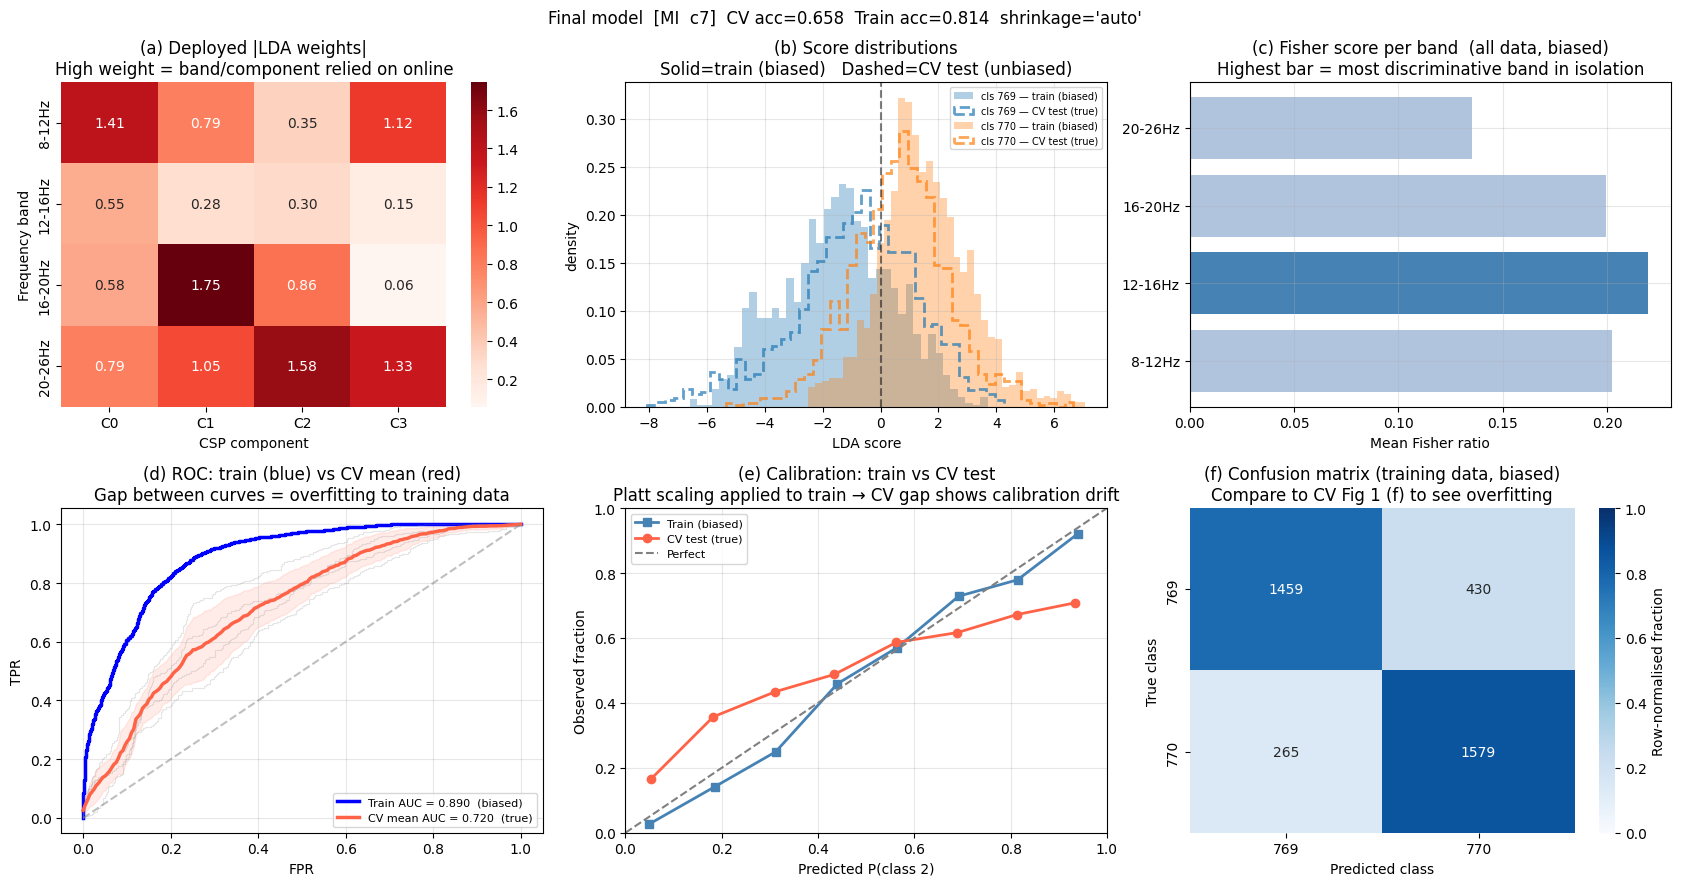

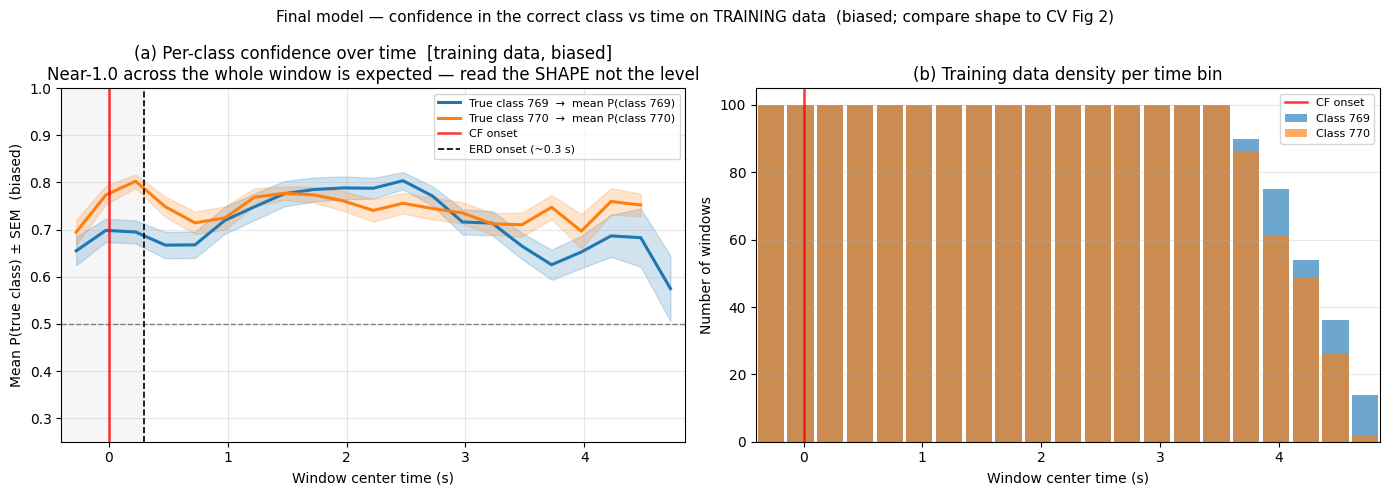

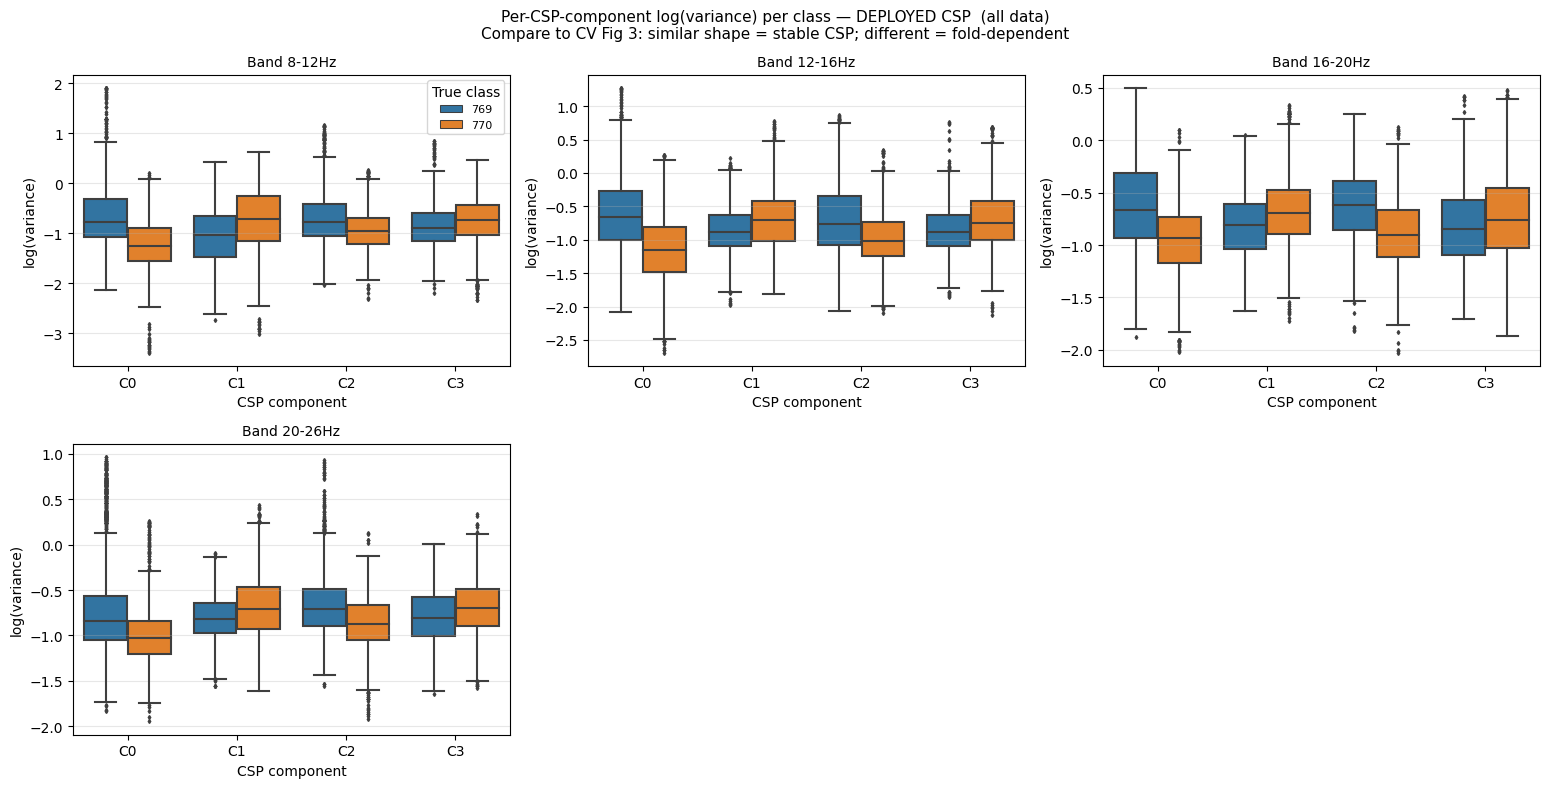

In [6]:
# ── All-data CSP fit (deployed model — no held-out set) ──────────────────
csp_list  = [CSP(n_components=N_CSP_COMPONENTS, reg='ledoit_wolf', log=True,
                 norm_trace=False, component_order='alternate')
             for _ in range(len(BANDS))]

X_csp_all = np.zeros((len(X_epochs), len(BANDS), N_CSP_COMPONENTS))
for b in range(len(BANDS)):
    X_b = X_epochs[:, b, SELECTED_INDEX_CH, :]
    csp_list[b].fit(X_b, y_epochs)
    X_csp_all[:, b, :] = csp_list[b].transform(X_b)

X_csp_sel  = X_csp_all[:, :, SELECTED_COMP]
X_features = flatten_csp(X_csp_sel, len(BANDS), n_sel)
print(f"CSP: {len(BANDS)} bands × {N_CSP_COMPONENTS} components | "
      f"Feature matrix: {X_features.shape}  [band-major]")

# ── Final model + Platt sigmoid calibration ───────────────────────────────
clf_final = LinearDiscriminantAnalysis(solver='lsqr', shrinkage=LDA_SHRINKAGE, priors=LDA_PRIORS)
clf_final.fit(X_features, y_epochs)

# Platt calibration 
y_bin = (all_y_true == classes[1]).astype(int)

sigmoid_calibrator = LogisticRegression(penalty=None)
sigmoid_calibrator.fit(all_scores.reshape(-1, 1), y_bin)
platt_a = float(sigmoid_calibrator.coef_[0][0])
platt_b = float(sigmoid_calibrator.intercept_[0])
print(f"[INFO] Platt sigmoid calibrata su CV: a={platt_a:.3f}  b={platt_b:.3f}")

scores_final    = clf_final.decision_function(X_features)
y_pred_final    = clf_final.predict(X_features)
final_train_acc = balanced_accuracy_score(y_epochs, y_pred_final)
cms_final       = confusion_matrix(y_epochs, y_pred_final, labels=classes)

# P(predicted = true class) on training data — biased confidence
prob_class1_tr = 1 / (1 + np.exp(-scores_final))
prob_correct_tr = np.where(y_epochs == classes[1], prob_class1_tr, 1 - prob_class1_tr)

# ── Summary ───────────────────────────────────────────────────────────────
sep = "─" * 56
print(f"\n{sep}")
print(f"  FINAL MODEL  ({len(X_epochs)} windows / {len(np.unique(trials))} trials)")
print(f"{sep}")
print(f"  CV accuracy (true generalisation)  : {mean_acc:.3f} ± {std_acc:.3f}")
print(f"  Train accuracy (biased — expected) : {final_train_acc:.3f}")
if platt_a is not None:
    print(f"  Platt sigmoid: a={platt_a:.3f}  b={platt_b:.3f}")
print(f"{sep}\n")

# ── Shared data for plots ─────────────────────────────────────────────────
fpr_tr, tpr_tr, _ = roc_curve((y_epochs == classes[1]).astype(int), scores_final)
auc_tr  = auc(fpr_tr, tpr_tr)
prob_tr = prob_class1_tr
prob_cv = 1 / (1 + np.exp(-all_scores))
mean_fpr_cv = np.linspace(0, 1, 200)
tprs_cv_i   = [np.interp(mean_fpr_cv, f, t) for f, t in zip(fold_fpr_list, fold_tpr_list)]


# ── Fig 5: final model analyses (mirrors CV Fig 1) ────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle(
    f"Final model  [{paradigm_to_save.upper()}  {subject}]  "
    f"CV acc={mean_acc:.3f}  Train acc={final_train_acc:.3f}  "
    f"shrinkage={LDA_SHRINKAGE!r}",
    fontsize=12)

# (a) Deployed LDA weight heatmap
ax = axes[0, 0]
sns.heatmap(np.abs(clf_final.coef_[0].reshape(len(BANDS), n_sel)),
            annot=True, fmt='.2f', cmap='Reds',
            xticklabels=[f'C{j}' for j in SELECTED_COMP],
            yticklabels=BANDS_STR, ax=ax)
ax.set(xlabel='CSP component', ylabel='Frequency band',
       title='(a) Deployed |LDA weights|\nHigh weight = band/component relied on online')

# (b) Score distributions: training (solid) vs CV test (dashed)
ax = axes[0, 1]
for i, cls in enumerate(classes):
    ax.hist(scores_final[y_epochs == cls], bins=40, alpha=0.35, density=True,
            color=f'C{i}', label=f'cls {cls} — train (biased)')
    ax.hist(all_scores[all_y_true == cls], bins=40, alpha=0.7, density=True,
            color=f'C{i}', histtype='step', lw=2, linestyle='--',
            label=f'cls {cls} — CV test (true)')
ax.axvline(0, color='k', linestyle='--', alpha=0.5)
ax.set(xlabel='LDA score', ylabel='density',
       title='(b) Score distributions\nSolid=train (biased)   Dashed=CV test (unbiased)')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (c) Fisher discriminability per frequency band
ax = axes[0, 2]
fisher_per_band = [np.mean(get_fisher_score(
    X_features[:, b * n_sel:(b + 1) * n_sel], y_epochs, classes))
    for b in range(len(BANDS))]
colors_f = ['steelblue' if f == max(fisher_per_band) else 'lightsteelblue'
            for f in fisher_per_band]
ax.barh(range(len(BANDS)), fisher_per_band, color=colors_f)
ax.set_yticks(range(len(BANDS))); ax.set_yticklabels(BANDS_STR)
ax.set(xlabel='Mean Fisher ratio',
       title='(c) Fisher score per band  (all data, biased)\n'
             'Highest bar = most discriminative band in isolation')
ax.grid(alpha=0.3)

# (d) ROC: train vs CV mean
ax = axes[1, 0]
ax.plot(fpr_tr, tpr_tr, 'b', lw=2.5, label=f'Train AUC = {auc_tr:.3f}  (biased)')
for fpr_f, tpr_f in zip(fold_fpr_list, fold_tpr_list):
    ax.plot(fpr_f, tpr_f, color='gray', alpha=0.2, lw=0.8)
ax.plot(mean_fpr_cv, np.mean(tprs_cv_i, 0), 'tomato', lw=2.5,
        label=f'CV mean AUC = {np.mean(auc_scores):.3f}  (true)')
ax.fill_between(mean_fpr_cv,
                np.mean(tprs_cv_i, 0) - np.std(tprs_cv_i, 0),
                np.mean(tprs_cv_i, 0) + np.std(tprs_cv_i, 0),
                alpha=0.12, color='tomato')
ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
ax.set(xlabel='FPR', ylabel='TPR',
       title='(d) ROC: train (blue) vs CV mean (red)\n'
             'Gap between curves = overfitting to training data')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (e) Calibration: train vs CV test
ax = axes[1, 1]
frac_tr_c, pred_tr_c = calibration_curve(
    (y_epochs == classes[1]).astype(int), prob_tr, n_bins=8, strategy='uniform')
frac_cv_c, pred_cv_c = calibration_curve(
    (all_y_true == classes[1]).astype(int), prob_cv, n_bins=8, strategy='uniform')
ax.plot(pred_tr_c, frac_tr_c, 's-', lw=2, color='steelblue', label='Train (biased)')
ax.plot(pred_cv_c, frac_cv_c, 'o-', lw=2, color='tomato',    label='CV test (true)')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect')
ax.set(xlabel='Predicted P(class 2)', ylabel='Observed fraction',
       title='(e) Calibration: train vs CV test\n'
             'Platt scaling applied to train → CV gap shows calibration drift',
       xlim=[0, 1], ylim=[0, 1])
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (f) Confusion matrix on training data (biased)
ax = axes[1, 2]
cms_norm = cms_final / cms_final.sum(axis=1, keepdims=True)
sns.heatmap(cms_norm, annot=cms_final.astype(int), fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax, vmin=0, vmax=1,
            cbar_kws={'label': 'Row-normalised fraction'})
ax.set(xlabel='Predicted class', ylabel='True class',
       title='(f) Confusion matrix (training data, biased)\n'
             'Compare to CV Fig 1 (f) to see overfitting')

plt.tight_layout(); plt.show()


# ── Fig 6: P(predicted=true class) vs time — final model on training data ─
BINS_TR = np.arange(round(t_centers.min(), 1), round(t_centers.max(), 1) + 0.25, 0.25)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Final model — confidence in the correct class vs time on TRAINING data  "
    "(biased; compare shape to CV Fig 2)",
    fontsize=11)

ax = axes[0]
for c_i, cls in enumerate(classes):
    mask = y_epochs == cls
    df_c = pd.DataFrame({'t': t_centers[mask], 'p': prob_correct_tr[mask]})
    df_c['bin'] = pd.cut(df_c['t'], bins=BINS_TR)
    grp    = df_c.groupby('bin', observed=True)['p']
    b_mean = grp.mean()
    b_sem  = grp.std() / np.sqrt(grp.count())
    t_mid  = np.array([b.mid for b in b_mean.index])
    ax.plot(t_mid, b_mean.values, color=f'C{c_i}', lw=2.2,
            label=f'True class {cls}  →  mean P(class {cls})')
    ax.fill_between(t_mid,
                    b_mean.values - b_sem.values,
                    b_mean.values + b_sem.values,
                    alpha=0.2, color=f'C{c_i}')

ax.axhline(0.5, color='gray', linestyle='--', lw=1)
ax.axvline(0.0, color='red', lw=1.8, alpha=0.8, label='CF onset')
if paradigm_to_save == 'mi':
    ax.axvspan(t_centers.min(), 0.3, alpha=0.07, color='gray')
    ax.axvline(0.3, color='k', lw=1.2, linestyle='--', label='ERD onset (~0.3 s)')
elif paradigm_to_save == 'cvsa':
    ax.axvspan(0, 0.7, alpha=0.07, color='orange')
    ax.axvline(0.7, color='darkorange', lw=1.2, linestyle='--', label='VEP decay (~0.7 s)')

ax.set(xlabel='Window center time (s)', ylabel='Mean P(true class) ± SEM  (biased)',
       xlim=[BINS_TR[0], BINS_TR[-1]], ylim=[0.25, 1.0],
       title='(a) Per-class confidence over time  [training data, biased]\n'
             'Near-1.0 across the whole window is expected — read the SHAPE not the level')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
for c_i, cls in enumerate(classes):
    mask = y_epochs == cls
    counts, edges = np.histogram(t_centers[mask], bins=BINS_TR)
    mid = (edges[:-1] + edges[1:]) / 2
    ax.bar(mid, counts, width=0.22, alpha=0.65, color=f'C{c_i}',
           label=f'Class {cls}', align='center')
ax.axvline(0.0, color='red', lw=1.8, alpha=0.8, label='CF onset')
if paradigm_to_save == 'cvsa' and CVSA_INFLUENCE is not None:
    ax.axvline(CVSA_INFLUENCE, color='purple', lw=1.2, linestyle='-.',
               label=f'CVSA_INFLUENCE = {CVSA_INFLUENCE} s')

ax.set(xlabel='Window center time (s)', ylabel='Number of windows',
       xlim=[BINS_TR[0], BINS_TR[-1]],
       title='(b) Training data density per time bin')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()


# ── Fig 7: per-CSP-component log(variance) per class — deployed CSP ───────
# Same plot as CV Fig 3 but using the DEPLOYED CSP filters (fit on all data).
# These are the values the online classifier will actually see at inference time.
# Discrepancies between this plot and CV Fig 3 indicate fold-dependent CSP instability.

n_bands_plot = len(BANDS)
nrows = int(np.ceil(n_bands_plot / 3))
ncols = min(3, n_bands_plot)
fig, axes_grid = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4 * nrows), squeeze=False)
axes_flat = axes_grid.flatten()
palette = {classes[0]: 'C0', classes[1]: 'C1'}

for b in range(n_bands_plot):
    ax = axes_flat[b]
    data_b = X_csp_all[:, b, :]
    df_b = pd.DataFrame(data_b, columns=[f'C{c}' for c in range(N_CSP_COMPONENTS)])
    df_b['class'] = y_epochs
    df_long = df_b.melt(id_vars='class', var_name='Component', value_name='log(variance)')
    sns.boxplot(data=df_long, x='Component', y='log(variance)', hue='class',
                palette=palette, ax=ax, fliersize=2)
    ax.set_title(f'Band {BANDS_STR[b]}', fontsize=10)
    ax.set_xlabel('CSP component')
    ax.grid(alpha=0.3, axis='y')
    if b > 0:
        ax.get_legend().remove()
    else:
        ax.legend(title='True class', fontsize=8)

for i in range(n_bands_plot, len(axes_flat)):
    axes_flat[i].set_visible(False)

fig.suptitle("Per-CSP-component log(variance) per class — DEPLOYED CSP  (all data)\n"
             "Compare to CV Fig 3: similar shape = stable CSP; different = fold-dependent",
             fontsize=11)
plt.tight_layout()
plt.show()


In [8]:
# ===WARNING===
# The exact feature concatenation order is:
# [band0_comp0..band0_compN | band1_comp0..band1_compN | ...]
# Fbcsp.cpp must apply filters and concatenate features in this exact same order.
# TODO: cross-check against the C++ implementation.
time_str = time.strftime('%d%m%Y_%H%M%S')

csp_matrices = []
for b in range(len(BANDS)):
    csp = csp_list[b]
    filters = csp.filters_
    sel_filters = filters[selected_indices, :]
    csp_matrices.append(sel_filters.tolist())

csp_dict = {
    'CspCfg': {
        'params':{
            'filenames': list(filenames), 
            'subject': subject,
            'name': 'csp',
            'classes': [str(c) for c in classes],
            'bands': BANDS,
            'selected_components_indices': selected_indices,
            'selected_channels': SELECTED_CHANNELS,   # channel names used – loaded by Fbcsp.cpp
            'csp_matrices': csp_matrices
        }
    }
}

yaml_csp_filename = current_dir + f'/src/processing_bci/cfg/csp/{paradigm_to_save}/csp_{subject}_{time_str}.yaml'
with open(yaml_csp_filename, 'w') as f:
    yaml.dump(csp_dict, f, default_flow_style=False, sort_keys=False)
print(f"[OK] CSP matrices saved in {yaml_csp_filename}")

slda_dict = {
    'sLDACfg':{
        'params':{
            'filenames': list(filenames), 
            'subject': subject,
            'name': 'slda',
            'classes': [str(c) for c in classes],
            'bands': BANDS,
            'selected_components_indices': selected_indices,
            'selected_channels': SELECTED_CHANNELS,
            'cv_mean_acc': float(mean_acc),
            'cv_std_acc': float(std_acc),
            'confusion_matrix': mean_cm.tolist(),
            'csp': yaml_csp_filename,
            'slda_weights': clf_final.coef_.tolist(),
            'slda_intercept': clf_final.intercept_.tolist(),
            'slda_calibrated_weights': [platt_a] if platt_a is not None else [],
            'slda_calibrated_intercept': [platt_b] if platt_b is not None else [],
        }
    }
}

yaml_metadata_filename = current_dir + f'/src/slda_bci/models/{paradigm_to_save}/slda_{subject}_{time_str}.yaml'
with open(yaml_metadata_filename, 'w') as f:
    yaml.dump(slda_dict, f, default_flow_style=False, sort_keys=False)
print(f"[OK] sLDA model saved in {yaml_metadata_filename}")


[OK] CSP matrices saved in /home/paolo/bci_vr_ws/src/processing_bci/cfg/csp/mi/csp_c7_20052026_181910.yaml
[OK] sLDA model saved in /home/paolo/bci_vr_ws/src/slda_bci/models/mi/slda_c7_20052026_181910.yaml



Spatial pattern band: 8-12Hz:
[OK] Topoplot saved in: /home/paolo/bci_vr_ws/images/c7/csp/topoplot_c7_8_12Hz_mi_lhrh.png

Spatial pattern band: 12-16Hz:
[OK] Topoplot saved in: /home/paolo/bci_vr_ws/images/c7/csp/topoplot_c7_12_16Hz_mi_lhrh.png

Spatial pattern band: 16-20Hz:
[OK] Topoplot saved in: /home/paolo/bci_vr_ws/images/c7/csp/topoplot_c7_16_20Hz_mi_lhrh.png

Spatial pattern band: 20-26Hz:
[OK] Topoplot saved in: /home/paolo/bci_vr_ws/images/c7/csp/topoplot_c7_20_26Hz_mi_lhrh.png


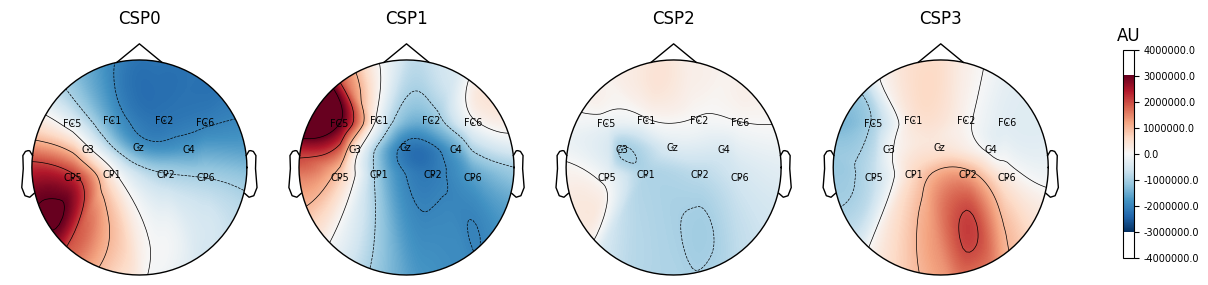

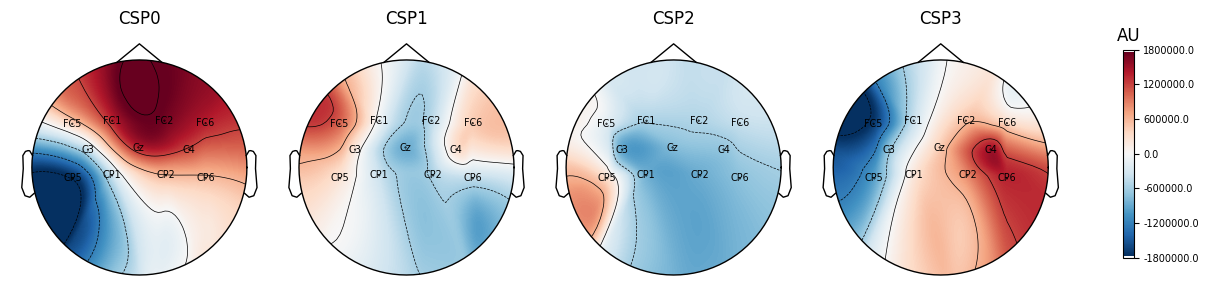

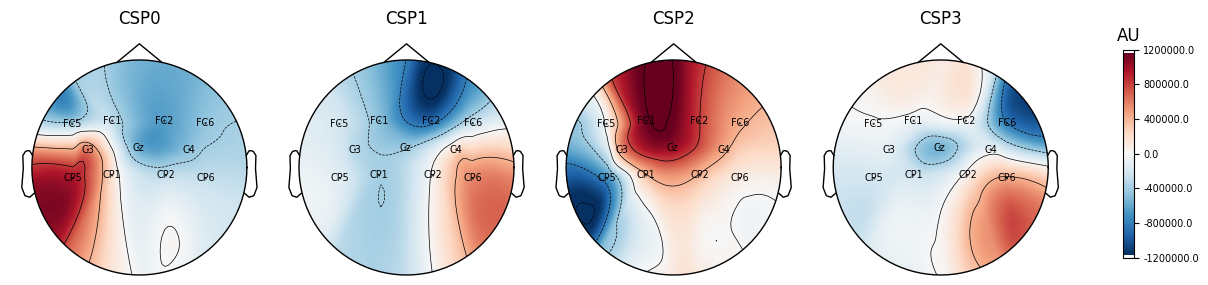

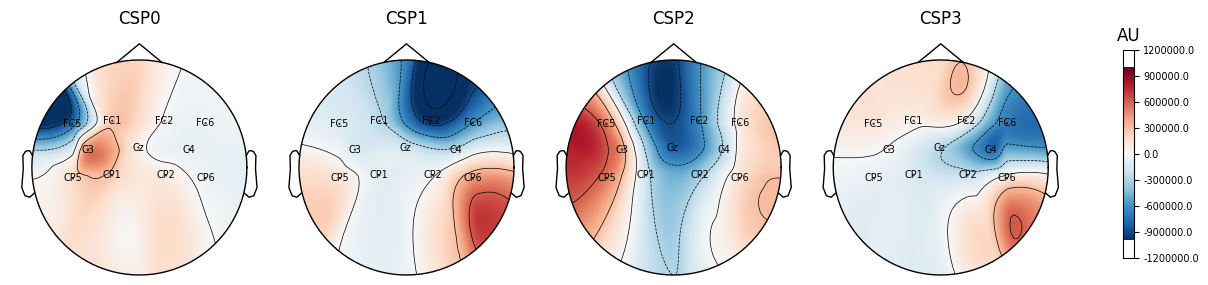

In [7]:
plot_dir = os.path.join(current_dir, f"images/{subject}/csp")
os.makedirs(plot_dir, exist_ok=True)

info_full = raw_list[0].info
montage = mne.channels.make_standard_montage('standard_1020')
info_full.set_montage(montage, on_missing='ignore')
info_limited = mne.pick_info(info_full, sel=SELECTED_INDEX_CH)

for b in range(len(BANDS)):
    print(f"\nSpatial pattern band: {BANDS_STR[b]}:")
    
    fig = csp_list[b].plot_patterns(info_limited, 
                                    components=selected_indices, 
                                    size=2.0, 
                                    show_names=True,
                                    show=False) 
    
    clean_band_name = BANDS_STR[b].replace("-", "_").replace(" ", "")
    
    plot_filename = os.path.join(plot_dir, f"topoplot_{subject}_{clean_band_name}_{paradigm}.png")
    
    fig.savefig(plot_filename, dpi=300, bbox_inches='tight', transparent=False)
    
    print(f"[OK] Topoplot saved in: {plot_filename}")